# Environment Setup

In [1]:
import sys
import os

# Ensure project root is in path
sys.path.append(os.path.abspath(".."))

# Imports

In [2]:
import importlib
import pandas as pd
import matplotlib.pyplot as plt

import model.assumptions as assumptions_module
import model.policy as policy_module
import model.projection as projection_module
import model.valuation as valuation_module
import model.results as results_module
import model.analysis.profit as profit_analysis

plt.style.use("seaborn-v0_8")

# Reload Modules

In [3]:
def reload_all():

    importlib.reload(assumptions_module)
    importlib.reload(policy_module)
    importlib.reload(projection_module)
    importlib.reload(results_module)
    importlib.reload(valuation_module)
    importlib.reload(profit_analysis)

reload_all()

# Notebook Entry Points 
import model.valuation as valuation 
import model.analysis.profit as profit_analysis 
import model.assumptions as assumptions_module 
import model.policy as policy_module

# Assumptions Setup

In [4]:
mortality = assumptions_module.MortalityTable()

interest = assumptions_module.FlatYieldCurve(
    interest_rate=0.03
)

lapse_table = assumptions_module.load_lapse_table(
    "../data/lapse_rates.csv"
)

assumptions = assumptions_module.AssumptionSet(
    mortality=mortality,
    interest=interest,
    lapse=lapse_table
)

# Single Policy Setup

In [5]:
policy = policy_module.Policy(
    age=40,
    term=20,
    sum_assured=100000,
    premium=1200,
    smoker_status="Non-Smoker",
    product_type="Term"
)

# Projection Analysis

In [6]:
projection = projection_module.project_cashflows(
    policy,
    assumptions
)

projection

projection.rows[5]

ProjectionRow(t=5, age=45, prob_inforce=0.744148, qx=0.001660)

# Run valuation

In [7]:
valuation_result = valuation_module.value_policy(
    policy,
    assumptions,
    return_breakdown=True
)

# Core results

In [8]:
summary = {
    "PV Premiums": valuation_result.pv_premiums,
    "PV Claims": valuation_result.pv_claims,
    "Net Value": valuation_result.net_value
}

pd.Series(summary)

PV Premiums    12921.025156
PV Claims       2413.186098
Net Value      10507.839059
dtype: float64

# Build Analysis Dataset

In [9]:
df = profit_analysis.build_profit_dataframe(valuation_result)
df = profit_analysis.add_profit_signature(df)

# Profit Emergence Table

In [10]:
df[["t",
    "net_cashflow",
    "cum_cashflow",
    "pv_net",
    "cum_profit"
]].round(2)

,t,net_cashflow,cum_cashflow,pv_net,cum_profit
0,0,1088.72,1088.72,1088.72,1088.72
1,1,991.90,2080.62,963.01,2051.73
2,2,932.35,3012.97,878.83,2930.56
3,3,875.52,3888.50,801.23,3731.79
4,4,821.26,4709.76,729.68,4461.47
5,5,769.45,5479.21,663.73,5125.20
6,6,735.12,6214.33,615.65,5740.86
7,7,701.30,6915.62,570.22,6311.07
8,8,667.93,7583.56,527.27,6838.35
9,9,635.00,8218.55,486.67,7325.02


# Profit Signature

In [11]:
df[["t", "pv_net", "profit_pct"]].round(4)

,t,pv_net,profit_pct
0,0,1088.7230,0.1036
1,1,963.0072,0.0916
2,2,878.8329,0.0836
3,3,801.2275,0.0763
4,4,729.6829,0.0694
5,5,663.7301,0.0632
6,6,615.6526,0.0586
7,7,570.2180,0.0543
8,8,527.2724,0.0502
9,9,486.6713,0.0463


# Summary Metrics

In [12]:
pd.Series(profit_analysis.summary_metrics(df))

total_pv_profit      10507.839059
total_cash_profit    13019.617165
peak_profit_year         0.000000
dtype: float64

# Visualisations

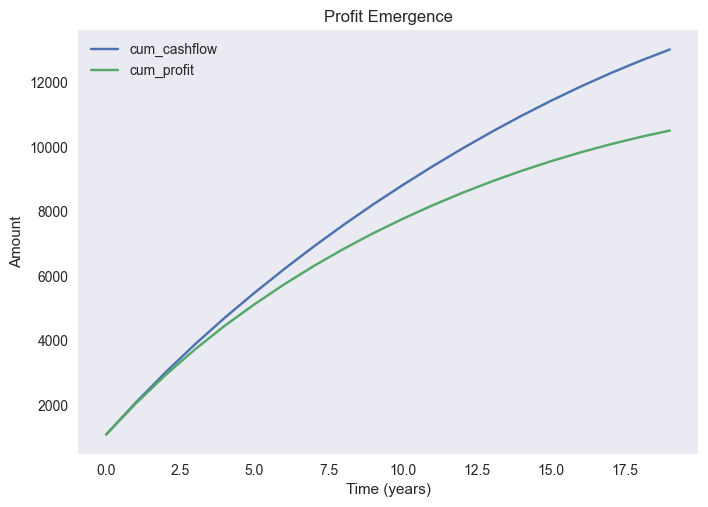

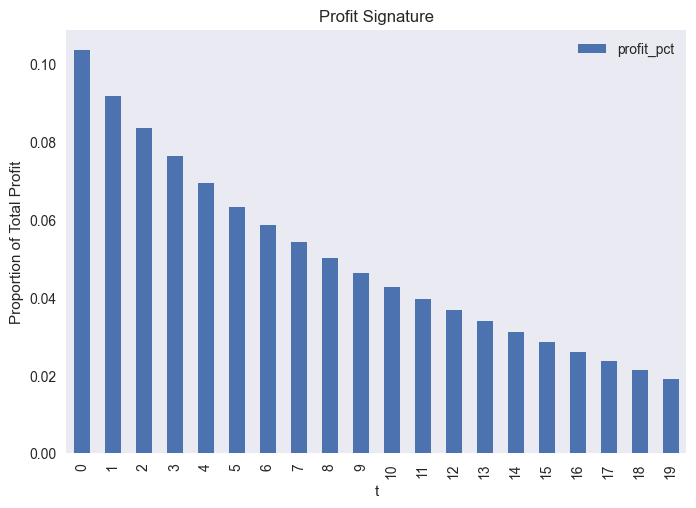

In [13]:
# Profit Emergence

df.plot(x="t", y=["cum_cashflow", "cum_profit"])
plt.title("Profit Emergence")
plt.ylabel("Amount")
plt.xlabel("Time (years)")
plt.grid()
plt.show()


# Profit Signature

df.plot(x="t", y="profit_pct", kind="bar")
plt.title("Profit Signature")
plt.ylabel("Proportion of Total Profit")
plt.grid()
plt.show()